#**RFdiffusion v1.1.1**
RFdiffusion is a method for structure generation, with or without conditional information (a motif, target etc). It can perform a whole range of protein design challenges as we have outlined in the RFdiffusion [manuscript](https://www.biorxiv.org/content/10.1101/2022.12.09.519842v2).


For **instructions**, see end of Notebook.

**<font color="red">NOTE:</font>**  This is tagged v1.1.1 of the notebook, this notebook may break in the future when colab updates. For latest version see [main](https://colab.research.google.com/github/sokrypton/ColabDesign/blob/main/rf/examples/diffusion.ipynb) branch.

Additional Notebooks:

- See [diffusion_foldcond](https://colab.research.google.com/github/sokrypton/ColabDesign/blob/v1.1.1/rf/examples/diffusion_foldcond.ipynb) for fold conditioning functionality.

- See [original version](https://colab.research.google.com/github/sokrypton/ColabDesign/blob/v1.1.1/rf/examples/diffusion_ori.ipynb) of this notebook (from 31Mar2023).


In [1]:
import os
import sys
import time
import json
import numpy as np
import matplotlib.pyplot as plt
import py3Dmol

# Define base directory
BASE_DIR = "/clusterfs/nilah/sergio/RFdifussion"
RFDIFFUSION_DIR = os.path.join(BASE_DIR, "RFdiffusion", "rfdiffusion")
MODEL_DIR = os.path.join(BASE_DIR, "RFdiffusion", "models")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
SCHEDULES_DIR = os.path.join(BASE_DIR, "RFdiffusion", "schedules")

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Debug sys.path and directories
print("sys.path:", sys.path)
print("BASE_DIR:", BASE_DIR)
print("RFDIFFUSION_DIR:", RFDIFFUSION_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("SCHEDULES_DIR:", SCHEDULES_DIR)
print("Exists BASE_DIR:", os.path.exists(BASE_DIR))
print("Exists RFDIFFUSION_DIR:", os.path.exists(RFDIFFUSION_DIR))
print("Exists MODEL_DIR:", os.path.exists(MODEL_DIR))
print("Exists SCHEDULES_DIR:", os.path.exists(SCHEDULES_DIR))

# Verify ananas binary
ANANAS_PATH = os.path.join(BASE_DIR, "ananas")
if not os.path.exists(ANANAS_PATH):
    print("Downloading ananas...")
    os.system(f"wget -qnc https://files.ipd.uw.edu/krypton/ananas -O {ANANAS_PATH}")
    os.system(f"chmod +x {ANANAS_PATH}")

# Verify model files
required_models = ["Base_ckpt.pt", "Complex_base_ckpt.pt"]
for model in required_models:
    model_path = os.path.join(MODEL_DIR, model)
    print(f"Checking model: {model_path}")
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file {model} not found at {model_path}")

# Verify schedules directory
if not os.path.exists(SCHEDULES_DIR):
    raise FileNotFoundError(f"Schedules directory not found at {SCHEDULES_DIR}")

# Add RFdiffusion to sys.path
if RFDIFFUSION_DIR not in sys.path:
    os.environ["DGLBACKEND"] = "pytorch"
    sys.path.append(RFDIFFUSION_DIR)
    print(f"Added {RFDIFFUSION_DIR} to sys.path")

# Import RFdiffusion utilities
try:
    from inference.utils import parse_pdb
    from colabdesign.rf.utils import get_ca, fix_contigs, fix_partial_contigs, fix_pdb, sym_it
    from colabdesign.shared.protein import pdb_to_string
except ImportError as e:
    print(f"Error importing utilities: {e}")
    print("Ensure ColabDesign is installed: pip install git+https://github.com/sokrypton/ColabDesign.git@v1.1.1")
    print("Verify RFdiffusion directory at", RFDIFFUSION_DIR)
    print("Contents of RFDIFFUSION_DIR:", os.listdir(RFDIFFUSION_DIR))
    raise

def get_pdb(pdb_code=None):
    """Retrieve or validate PDB file."""
    if pdb_code is None or pdb_code == "":
        raise ValueError("No PDB code provided.")
    elif os.path.isfile(pdb_code):
        return pdb_code
    elif len(pdb_code) == 4:
        pdb_file = os.path.join(BASE_DIR, f"{pdb_code}.pdb1")
        if not os.path.exists(pdb_file):
            os.system(f"wget -qnc https://files.rcsb.org/download/{pdb_code}.pdb1.gz -O {pdb_file}.gz")
            os.system(f"gunzip {pdb_file}.gz")
        return pdb_file
    else:
        pdb_file = os.path.join(BASE_DIR, f"AF-{pdb_code}-F1-model_v3.pdb")
        if not os.path.exists(pdb_file):
            os.system(f"wget -qnc https://alphafold.ebi.ac.uk/files/AF-{pdb_code}-F1-model_v3.pdb -O {pdb_file}")
        return pdb_file

def run_ananas(pdb_str, path, sym=None):
    """Run AnAnaS for symmetry detection."""
    os.makedirs(os.path.join(OUTPUT_DIR, path), exist_ok=True)
    pdb_filename = os.path.join(OUTPUT_DIR, path, "ananas_input.pdb")
    out_filename = os.path.join(OUTPUT_DIR, path, "ananas.json")
    with open(pdb_filename, "w") as handle:
        handle.write(pdb_str)

    cmd = f"{ANANAS_PATH} {pdb_filename} -u -j {out_filename}"
    if sym:
        cmd += f" {sym}"
    os.system(cmd)

    try:
        out = json.loads(open(out_filename, "r").read())
        results, AU = out[0], out[-1]["AU"]
        group = AU["group"]
        chains = AU["chain names"]
        rmsd = results["Average_RMSD"]
        print(f"AnAnaS detected {group} symmetry at RMSD:{rmsd:.3}")

        C = np.array(results['transforms'][0]['CENTER'])
        A = [np.array(t["AXIS"]) for t in results['transforms']]

        new_lines = []
        for line in pdb_str.split("\n"):
            if line.startswith("ATOM"):
                chain = line[21:22]
                if chain in chains:
                    x = np.array([float(line[i:(i+8)]) for i in [30, 38, 46]])
                    if group[0] == "c":
                        x = sym_it(x, C, A[0])
                    if group[0] == "d":
                        x = sym_it(x, C, A[1], A[0])
                    coord_str = "".join(["{:8.3f}".format(a) for a in x])
                    new_lines.append(line[:30] + coord_str + line[54:])
            else:
                new_lines.append(line)
        return results, "\n".join(new_lines)
    except:
        return None, pdb_str

def run(command, steps, num_designs=1, visual="none"):
    """Execute RFdiffusion command and monitor progress."""
    def run_command_and_get_pid(command):
        pid_file = os.path.join(BASE_DIR, "pid")
        os.system(f'{command} > {BASE_DIR}/run.log 2>&1 & echo $! > {pid_file}')
        with open(pid_file, 'r') as f:
            pid = int(f.read().strip())
        os.remove(pid_file)
        return pid

    def is_process_running(pid):
        try:
            os.kill(pid, 0)
            return True
        except OSError:
            return False

    print(f"Running command: {command}")
    pid = run_command_and_get_pid(command)
    try:
        for _ in range(num_designs):
            for n in range(steps):
                wait = True
                while wait:
                    time.sleep(1)
                    pdb_file = os.path.join(BASE_DIR, f"{n}.pdb")
                    if os.path.exists(pdb_file):
                        with open(pdb_file, "r") as f:
                            pdb_str = f.read()
                        if pdb_str.strip().endswith("TER"):
                            wait = False
                        elif not is_process_running(pid):
                            print("Process failed.")
                            return
                    elif not is_process_running(pid):
                        print("Process terminated unexpectedly.")
                        return

                if visual != "none":
                    if visual == "image":
                        xyz, bfact = get_ca(pdb_file, get_bfact=True)
                        fig = plt.figure(figsize=(6, 6), dpi=100)
                        ax = fig.add_subplot(111)
                        ax.set_xticks([]); ax.set_yticks([])
                        plot_pseudo_3D(xyz, c=bfact, cmin=0.5, cmax=0.9, ax=ax)
                        plt.savefig(os.path.join(OUTPUT_DIR, f"step_{n}.png"))
                        plt.close()
                    elif visual == "interactive":
                        view = py3Dmol.view()
                        view.addModel(pdb_str, 'pdb')
                        view.setStyle({'cartoon': {'colorscheme': {'prop': 'b', 'gradient': 'roygb', 'min': 0.5, 'max': 0.9}}})
                        view.zoomTo()
                        view.save_html(os.path.join(OUTPUT_DIR, f"step_{n}.html"))

                if os.path.exists(pdb_file):
                    os.remove(pdb_file)

        while is_process_running(pid):
            time.sleep(1)

    except KeyboardInterrupt:
        os.system(f"kill -TERM {pid}")
        print("Process stopped.")

def run_diffusion(contigs, path, pdb=None, iterations=50,
                  symmetry="none", order=1, hotspot=None,
                  chains=None, add_potential=False,
                  num_designs=1, visual="none"):
    """Run RFdiffusion inference."""
    full_path = os.path.join(OUTPUT_DIR, path)
    os.makedirs(full_path, exist_ok=True)
    opts = [f"inference.output_prefix={full_path}",
            f"inference.num_designs={num_designs}"]

    if chains == "":
        chains = None

    # Determine symmetry type
    if symmetry in ["auto", "cyclic", "dihedral"]:
        if symmetry == "auto":
            sym, copies = None, 1
        else:
            sym, copies = {"cyclic": (f"c{order}", order),
                          "dihedral": (f"d{order}", order*2)}[symmetry]
    else:
        symmetry = None
        sym, copies = None, 1

    # Determine mode
    contigs = contigs.replace(",", " ").replace(":", " ").split()
    is_fixed, is_free = False, False
    fixed_chains = []
    for contig in contigs:
        for x in contig.split("/"):
            a = x.split("-")[0]
            if a[0].isalpha():
                is_fixed = True
                if a[0] not in fixed_chains:
                    fixed_chains.append(a[0])
            if a.isnumeric():
                is_free = True
    if len(contigs) == 0 or not is_free:
        mode = "partial"
    elif is_fixed:
        mode = "fixed"
    else:
        mode = "free"

    # Fix input contigs
    if mode in ["partial", "fixed"]:
        pdb_str = pdb_to_string(get_pdb(pdb), chains=chains)
        if symmetry == "auto":
            a, pdb_str = run_ananas(pdb_str, path)
            if a is None:
                print("ERROR: no symmetry detected")
                symmetry = None
                sym, copies = None, 1
            else:
                if a["group"][0] == "c":
                    symmetry = "cyclic"
                    sym, copies = a["group"], int(a["group"][1:])
                elif a["group"][0] == "d":
                    symmetry = "dihedral"
                    sym, copies = a["group"], 2 * int(a["group"][1:])
                else:
                    print(f"ERROR: detected symmetry ({a['group']}) not supported")
                    symmetry = None
                    sym, copies = None, 1

        elif mode == "fixed":
            pdb_str = pdb_to_string(pdb_str, chains=fixed_chains)

        pdb_filename = os.path.join(full_path, "input.pdb")
        with open(pdb_filename, "w") as handle:
            handle.write(pdb_str)

        parsed_pdb = parse_pdb(pdb_filename)
        opts.append(f"inference.input_pdb={pdb_filename}")
        if mode == "partial":
            iterations = int(80 * (iterations / 200))
            opts.append(f"diffuser.partial_T={iterations}")
            contigs = fix_partial_contigs(contigs, parsed_pdb)
        else:
            opts.append(f"diffuser.T={iterations}")
            contigs = fix_contigs(contigs, parsed_pdb)
    else:
        opts.append(f"diffuser.T={iterations}")
        parsed_pdb = None
        contigs = fix_contigs(contigs, parsed_pdb)

    if hotspot and hotspot != "":
        opts.append(f"ppi.hotspot_res=[{hotspot}]")

    # Setup symmetry
    if sym is not None:
        sym_opts = ["--config-name symmetry", f"inference.symmetry={sym}"]
        if add_potential:
            sym_opts += ["'potentials.guiding_potentials=[\"type:olig_contacts,weight_intra:1,weight_inter:0.1\"]'",
                        "potentials.olig_intra_all=True", "potentials.olig_inter_all=True",
                        "potentials.guide_scale=2", "potentials.guide_decay=quadratic"]
        opts = sym_opts + opts
        contigs = sum([contigs] * copies, [])

    opts.append(f"'contigmap.contigs=[{' '.join(contigs)}]'")
    opts.append("inference.dump_pdb=True")
    opts.append(f"inference.dump_pdb_path={BASE_DIR}")

    print("Mode:", mode)
    print("Output:", full_path)
    print("Contigs:", contigs)

    opts_str = " ".join(opts)
    cmd = f"python {RFDIFFUSION_DIR}/scripts/run_inference.py {opts_str}"
    print("Command:", cmd)

    # Run
    run(cmd, iterations, num_designs, visual=visual)

    # Fix PDBs
    for n in range(num_designs):
        pdbs = [f"{full_path}/traj/{path}_{n}_pX0_traj.pdb",
                f"{full_path}/traj/{path}_{n}_Xt-1_traj.pdb",
                f"{full_path}_{n}.pdb"]
        for pdb in pdbs:
            if os.path.exists(pdb):
                with open(pdb, "r") as handle:
                    pdb_str = handle.read()
                with open(pdb, "w") as handle:
                    handle.write(fix_pdb(pdb_str, contigs))

    return contigs, copies

sys.path: ['/clusterfs/nilah/sergio/miniconda3/envs/SE3nv/lib/python39.zip', '/clusterfs/nilah/sergio/miniconda3/envs/SE3nv/lib/python3.9', '/clusterfs/nilah/sergio/miniconda3/envs/SE3nv/lib/python3.9/lib-dynload', '', '/global/home/users/sergiomar10/.local/lib/python3.9/site-packages', '/clusterfs/nilah/sergio/miniconda3/envs/SE3nv/lib/python3.9/site-packages', '/clusterfs/nilah/sergio/miniconda3/envs/SE3nv/lib/python3.9/site-packages/se3_transformer-1.0.0-py3.9.egg', '/clusterfs/nilah/sergio/RFdifussion/RFdiffusion']
BASE_DIR: /clusterfs/nilah/sergio/RFdifussion
RFDIFFUSION_DIR: /clusterfs/nilah/sergio/RFdifussion/RFdiffusion/rfdiffusion
MODEL_DIR: /clusterfs/nilah/sergio/RFdifussion/RFdiffusion/models
OUTPUT_DIR: /clusterfs/nilah/sergio/RFdifussion/outputs
SCHEDULES_DIR: /clusterfs/nilah/sergio/RFdifussion/RFdiffusion/schedules
Exists BASE_DIR: True
Exists RFDIFFUSION_DIR: True
Exists MODEL_DIR: True
Exists SCHEDULES_DIR: True
Checking model: /clusterfs/nilah/sergio/RFdifussion/RFdi

/clusterfs/nilah/sergio/RFdifussion/RFdiffusion/rfdiffusion/util.py:253: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647327249/work/aten/src/ATen/native/Cross.cpp:62.)
  Z = torch.cross(Xn, Yn)
/clusterfs/nilah/sergio/miniconda3/envs/SE3nv/lib/python3.9/site-packages/dgl/backend/pytorch/sparse.py:104: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=th.float16)
/clusterfs/nilah/sergio/miniconda3/envs/SE3nv/lib/python3.9/site-packages/dgl/backend/pytorch/sparse.py:128: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(c

In [8]:
%%time
#@title run **RFdiffusion** to generate a backbone
name = "RUN1" #@param {type:"string"}
contigs = "9" #@param {type:"string"}
pdb = "7rtd.pdb" #@param {type:"string"}
iterations = 50 #@param ["25", "50", "100", "150", "200"] {type:"raw"}
hotspot = "A7,A9,A59,A63,A66,A70,A99,A159,A167" #@param {type:"string"}
num_designs = 1 #@param ["1", "2", "4", "8", "16", "32"] {type:"raw"}
visual = "image" #@param ["none", "image", "interactive"]
#@markdown ---
#@markdown **symmetry** settings
#@markdown ---
symmetry = "none" #@param ["none", "auto", "cyclic", "dihedral"]
order = 1 #@param ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12"] {type:"raw"}
chains = "A,B,C" #@param {type:"string"}
add_potential = True #@param {type:"boolean"}
#@markdown - `symmetry='auto'` enables automatic symmetry dectection with [AnAnaS](https://team.inria.fr/nano-d/software/ananas/).
#@markdown - `chains="A,B"` filter PDB input to these chains (may help auto-symm detector)
#@markdown - `add_potential` to discourage clashes between chains

# determine where to save
path = name
while os.path.exists(f"outputs/{path}_0.pdb"):
  path = name + "_" + ''.join(random.choices(string.ascii_lowercase + string.digits, k=5))

flags = {"contigs":contigs,
         "pdb":pdb,
         "order":order,
         "iterations":iterations,
         "symmetry":symmetry,
         "hotspot":hotspot,
         "path":path,
         "chains":chains,
         "add_potential":add_potential,
         "num_designs":num_designs,
         "visual":visual}

for k,v in flags.items():
  if isinstance(v,str):
    flags[k] = v.replace("'","").replace('"','')

contigs, copies = run_diffusion(**flags)

Mode: free
Output: /clusterfs/nilah/sergio/RFdifussion/outputs/RUN1
Contigs: ['9-9']
Command: python /clusterfs/nilah/sergio/RFdifussion/RFdiffusion/rfdiffusion/run_inference.py inference.output_prefix=/clusterfs/nilah/sergio/RFdifussion/outputs/RUN1 inference.num_designs=1 diffuser.T=50 ppi.hotspot_res=[A7,A9,A59,A63,A66,A70,A99,A159,A167] 'contigmap.contigs=[9-9]' inference.dump_pdb=True inference.dump_pdb_path=/clusterfs/nilah/sergio/RFdifussion
Running command: python /clusterfs/nilah/sergio/RFdifussion/RFdiffusion/rfdiffusion/run_inference.py inference.output_prefix=/clusterfs/nilah/sergio/RFdifussion/outputs/RUN1 inference.num_designs=1 diffuser.T=50 ppi.hotspot_res=[A7,A9,A59,A63,A66,A70,A99,A159,A167] 'contigmap.contigs=[9-9]' inference.dump_pdb=True inference.dump_pdb_path=/clusterfs/nilah/sergio/RFdifussion
Process terminated unexpectedly.
CPU times: user 2.62 ms, sys: 44 µs, total: 2.66 ms
Wall time: 1.01 s


In [5]:
#@title Display 3D structure {run: "auto"}
animate = "none" #@param ["none", "movie", "interactive"]
color = "chain" #@param ["rainbow", "chain", "plddt"]
denoise = True
dpi = 100 #@param ["100", "200", "400"] {type:"raw"}
from colabdesign.shared.plot import pymol_color_list
from colabdesign.rf.utils import get_ca, get_Ls, make_animation
from string import ascii_uppercase,ascii_lowercase
alphabet_list = list(ascii_uppercase+ascii_lowercase)

def plot_pdb(num=0):
  if denoise:
    pdb_traj = f"/clusterfs/nilah/sergio/RFdifussion/outputs/traj/{path}_{num}_pX0_traj.pdb"
  else:
    pdb_traj = f"/clusterfs/nilah/sergio/RFdifussion/outputs/traj/{path}_{num}_Xt-1_traj.pdb"
  if animate in ["none","interactive"]:
    hbondCutoff = 4.0
    view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js')
    if animate == "interactive":
      pdb_str = open(pdb_traj,'r').read()
      view.addModelsAsFrames(pdb_str,'pdb',{'hbondCutoff':hbondCutoff})
    else:
      pdb = f"outputs/{path}_{num}.pdb"
      pdb_str = open(pdb,'r').read()
      view.addModel(pdb_str,'pdb',{'hbondCutoff':hbondCutoff})
    if color == "rainbow":
      view.setStyle({'cartoon': {'color':'spectrum'}})
    elif color == "chain":
      for n,chain,c in zip(range(len(contigs)),
                              alphabet_list,
                              pymol_color_list):
          view.setStyle({'chain':chain},{'cartoon': {'color':c}})
    else:
      view.setStyle({'cartoon': {'colorscheme': {'prop':'b','gradient': 'roygb','min':0.5,'max':0.9}}})
    view.zoomTo()
    if animate == "interactive":
      view.animate({'loop': 'backAndForth'})
    view.show()
  else:
    Ls = get_Ls(contigs)
    xyz, bfact = get_ca(pdb_traj, get_bfact=True)
    xyz = xyz.reshape((-1,sum(Ls),3))[::-1]
    bfact = bfact.reshape((-1,sum(Ls)))[::-1]
    if color == "chain":
      display(HTML(make_animation(xyz, Ls=Ls, dpi=dpi, ref=-1)))
    elif color == "rainbow":
      display(HTML(make_animation(xyz, dpi=dpi, ref=-1)))
    else:
      display(HTML(make_animation(xyz, plddt=bfact*100, dpi=dpi, ref=-1)))


if num_designs > 1:
  output = widgets.Output()
  def on_change(change):
    if change['name'] == 'value':
      with output:
        output.clear_output(wait=True)
        plot_pdb(change['new'])
  dropdown = widgets.Dropdown(
      options=[(f'{k}',k) for k in range(num_designs)],
      value=0, description='design:',
  )
  dropdown.observe(on_change)
  display(widgets.VBox([dropdown, output]))
  with output:
    plot_pdb(dropdown.value)
else:
  plot_pdb()

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/test2_0.pdb'

In [17]:
%%time
#@title run **ProteinMPNN** to generate a sequence and **AlphaFold** to validate
num_seqs = 64 #@param ["1", "2", "4", "8", "16", "32", "64"] {type:"raw"}
initial_guess = False #@param {type:"boolean"}
num_recycles = 1 #@param ["0", "1", "2", "3", "6", "12"] {type:"raw"}
use_multimer = False #@param {type:"boolean"}
rm_aa = "C" #@param {type:"string"}
mpnn_sampling_temp = 0.1 #@param ["0.0001", "0.1", "0.15", "0.2", "0.25", "0.3", "0.5", "1.0"] {type:"raw"}
#@markdown - for **binder** design, we recommend `initial_guess=True num_recycles=3`

if not os.path.isfile("params/done.txt"):
  print("downloading AlphaFold params...")
  while not os.path.isfile("params/done.txt"):
    time.sleep(5)

contigs_str = ":".join(contigs)
opts = [f"--pdb=outputs/{path}_0.pdb",
        f"--loc=outputs/{path}",
        f"--contig={contigs_str}",
        f"--copies={copies}",
        f"--num_seqs={num_seqs}",
        f"--num_recycles={num_recycles}",
        f"--rm_aa={rm_aa}",
        f"--mpnn_sampling_temp={mpnn_sampling_temp}",
        f"--num_designs={num_designs}"]
if initial_guess: opts.append("--initial_guess")
if use_multimer: opts.append("--use_multimer")
opts = ' '.join(opts)
!python colabdesign/rf/designability_test.py {opts}

{'pdb':'outputs/test2_0.pdb','loc':'outputs/test2','contigs':'9-9','copies':1,'num_seqs':64,'initial_guess':False,'use_multimer':False,'num_recycles':1,'rm_aa':'C','num_designs':1,'mpnn_sampling_temp':0.1}
protocol=fixbb
running proteinMPNN...
running AlphaFold...
design:0 n:0 mpnn:1.738 plddt:0.720 ptm:0.047 pae:4.798 rmsd:3.304 NEEELRSTR
design:0 n:1 mpnn:1.813 plddt:0.718 ptm:0.049 pae:4.609 rmsd:2.020 NEELLRSRR
design:0 n:2 mpnn:1.776 plddt:0.694 ptm:0.047 pae:5.120 rmsd:3.110 NVEEARSTR
design:0 n:3 mpnn:1.715 plddt:0.678 ptm:0.046 pae:5.570 rmsd:2.316 DVENARSTR
design:0 n:4 mpnn:1.757 plddt:0.749 ptm:0.052 pae:4.058 rmsd:1.431 NVEEALSRE
design:0 n:5 mpnn:1.781 plddt:0.804 ptm:0.054 pae:3.481 rmsd:2.719 NVEEARSKL
design:0 n:6 mpnn:1.728 plddt:0.783 ptm:0.047 pae:5.200 rmsd:3.441 DVENSRSTR
design:0 n:7 mpnn:1.872 plddt:0.796 ptm:0.050 pae:4.382 rmsd:1.951 NIEERMSKK
design:0 n:8 mpnn:1.769 plddt:0.694 ptm:0.047 pae:5.120 rmsd:3.110 NVEEARSTR
design:0 n:9 mpnn:1.748 plddt:0.716 ptm:0.

In [18]:
#@title Display best result
import py3Dmol
def plot_pdb(num = "best"):
  if num == "best":
    with open(f"outputs/{path}/best.pdb","r") as f:
      # REMARK 001 design {m} N {n} RMSD {rmsd}
      info = f.readline().strip('\n').split()
    num = info[3]
  hbondCutoff = 4.0
  view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js')
  pdb_str = open(f"outputs/{path}_{num}.pdb",'r').read()
  view.addModel(pdb_str,'pdb',{'hbondCutoff':hbondCutoff})
  pdb_str = open(f"outputs/{path}/best_design{num}.pdb",'r').read()
  view.addModel(pdb_str,'pdb',{'hbondCutoff':hbondCutoff})

  view.setStyle({"model":0},{'cartoon':{}}) #: {'colorscheme': {'prop':'b','gradient': 'roygb','min':0,'max':100}}})
  view.setStyle({"model":1},{'cartoon':{'colorscheme': {'prop':'b','gradient': 'roygb','min':0,'max':100}}})
  view.zoomTo()
  view.show()

if num_designs > 1:
  def on_change(change):
    if change['name'] == 'value':
      with output:
        output.clear_output(wait=True)
        plot_pdb(change['new'])
  dropdown = widgets.Dropdown(
    options=["best"] + [str(k) for k in range(num_designs)],
    value="best",
    description='design:',
  )
  dropdown.observe(on_change)
  output = widgets.Output()
  display(widgets.VBox([dropdown, output]))
  with output:
    plot_pdb(dropdown.value)
else:
  plot_pdb()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [19]:
!pip install logomaker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 10.8 MB/s eta 0:00:00


In [20]:
#@title Package and download results
#@markdown If you are having issues downloading the result archive,
#@markdown try disabling your adblocker and run this cell again.
#@markdown  If that fails click on the little folder icon to the
#@markdown  left, navigate to file: `name.result.zip`,
#@markdown  right-click and select \"Download\"
#@markdown (see [screenshot](https://pbs.twimg.com/media/E6wRW2lWUAEOuoe?format=jpg&name=small)).
!zip -r {path}.result.zip outputs/{path}* outputs/traj/{path}*
files.download(f"{path}.result.zip")

  adding: outputs/test2/ (stored 0%)
  adding: outputs/test2/all_pdb/ (stored 0%)
  adding: outputs/test2/all_pdb/design0_n6.pdb (deflated 76%)
  adding: outputs/test2/all_pdb/design0_n24.pdb (deflated 76%)
  adding: outputs/test2/all_pdb/design0_n11.pdb (deflated 76%)
  adding: outputs/test2/all_pdb/design0_n34.pdb (deflated 76%)
  adding: outputs/test2/all_pdb/design0_n26.pdb (deflated 76%)
  adding: outputs/test2/all_pdb/design0_n15.pdb (deflated 76%)
  adding: outputs/test2/all_pdb/design0_n8.pdb (deflated 76%)
  adding: outputs/test2/all_pdb/design0_n20.pdb (deflated 77%)
  adding: outputs/test2/all_pdb/design0_n53.pdb (deflated 76%)
  adding: outputs/test2/all_pdb/design0_n54.pdb (deflated 76%)
  adding: outputs/test2/all_pdb/design0_n41.pdb (deflated 76%)
  adding: outputs/test2/all_pdb/design0_n61.pdb (deflated 76%)
  adding: outputs/test2/all_pdb/design0_n4.pdb (deflated 76%)
  adding: outputs/test2/all_pdb/design0_n25.pdb (deflated 77%)
  adding: outputs/test2/all_pdb/design0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
import logomaker
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

data = pd.read_csv('mpnn_results.csv')

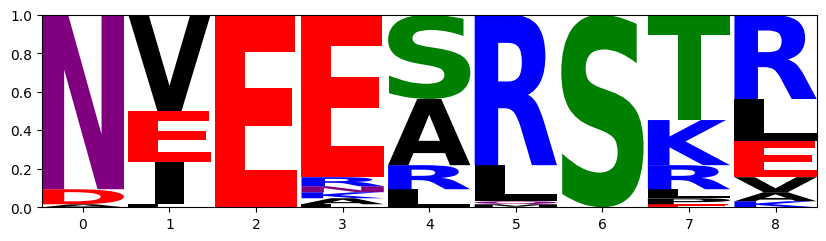

In [24]:

data = data[data['seq'].str.len() == 9]

sequences = data['seq'].tolist()

# Create a list of amino acids (standard 20 amino acids)
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

# Initialize a frequency matrix (9 positions x 20 amino acids)
num_positions = 9
freq_matrix = np.zeros((num_positions, len(amino_acids)))

# Populate the frequency matrix: count occurrences of each amino acid at each position
for seq in sequences:
    for i, aa in enumerate(seq):
        aa_index = amino_acids.index(aa)
        freq_matrix[i, aa_index] += 1

# Normalize the frequency matrix to get probabilities (frequencies sum to 1 at each position)
freq_matrix = freq_matrix / len(sequences)

# Create a DataFrame for logomaker
freq_df = pd.DataFrame(freq_matrix, columns=amino_acids)

# Generate the sequence logo
logo = logomaker.Logo(freq_df, color_scheme='chemistry', font_name='Arial Rounded MT Bold')


**Instructions**
---
---

Use `contigs` to define continious chains. Use a `:` to define multiple contigs and a `/` to define mutliple segments within a contig.
For example:

**unconditional**
- `contigs='100'` - diffuse **monomer** of length 100
- `contigs='50:100'` - diffuse **hetero-oligomer** of lengths 50 and 100
- `contigs='50'` `symmetry='cyclic'` `order=2` - make two copies of the defined contig(s) and add a symmetry constraint, for **homo-oligomeric** diffusion.

**binder design**
- `contigs='A:50'` `pdb='4N5T'` - diffuse a **binder** of length 50 to chain A of defined PDB.
- `contigs='E6-155:70-100'` `pdb='5KQV'` `hotspot='E64,E88,E96'` - diffuse a **binder** of length 70 to 100 (sampled randomly) to chain E and defined hotspot(s).

**motif scaffolding**
 - `contigs='40/A163-181/40'` `pdb='5TPN'`
 - `contigs='A3-30/36/A33-68'` `pdb='6MRR'` - diffuse a loop of length 36 between two segments of defined PDB ranges.

**partial diffusion**
- `contigs=''` `pdb='6MRR'` - noise all coordinates
- `contigs='A1-10'` `pdb='6MRR'` - keep first 10 positions fixed, noise the rest
- `contigs='A'` `pdb='1SSC'` - fix chain A, noise the rest

*hints and tips*
- `pdb=''` leave blank to get an upload prompt
- `contigs='50-100'` use dash to specify a range of lengths to sample from